In [0]:
%python
import pandas as pd

import pyspark.sql.functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt
import seaborn as sns


fact_seller_metrics = spark.table("marketplace_olist.gold.fact_seller_metrics")
fact_seller_metrics_smoothed = spark.table("marketplace_olist.gold.fact_seller_metrics_smoothed")
fact_seller_metrics_normalized = spark.table("marketplace_olist.gold.fact_seller_metrics_normalized")
fact_seller_index_components = spark.table("marketplace_olist.gold.fact_seller_index_components")
fact_seller_index = spark.table("marketplace_olist.gold.fact_seller_index")


#Seller Operational Index: Design and Construction
## 1. Business Role of the Seller Index

The Seller Operational Index is a central metric in the Olist marketplace ecosystem. It serves two main purposes.

 - First, it acts as an incentive mechanism to influence seller behavior. Olist partially subsidizes shipping costs depending on seller performance. Sellers with higher operational reliability receive greater support in logistics costs, which encourages them to improve fulfillment quality and delivery performance.

 - Second, the index directly affects Olist’s revenue structure. Since Olist shares part of the logistics costs with sellers, the way the index is constructed determines how these costs are distributed across the marketplace. This introduces several important trade-offs.

If the index thresholds are too permissive, sellers can easily reach high performance tiers with minimal operational effort. While this may attract more sellers and increase marketplace supply, it can also generate higher operational costs for Olist. Late shipments and cancellations may lead to additional logistics expenses, increased customer service workload, and lower customer satisfaction. Conversely, if the thresholds are too demanding, the index may fail to provide effective incentives. Sellers may perceive the targets as unattainable therefore make no effort to improve their operational performance. In addition, the prospect of facing high shipping cost without a prospect of cost reduction may discourage them from entering the marketplace in the first place, preventing profitable sales transactions for both OLIST and the sellers.

The challenge is therefore to design thresholds that are demanding yet attainable, aligning seller incentives with the platform’s operational efficiency and profitability.

## 2. Determinants of Seller Performance
The seller index is constructed from several operational indicators reflecting different aspects of seller reliability.

### 2.1 Late Shipments

Late shipments represent the most critical operational metric for Olist.

In the marketplace logistics model, Olist acts as an intermediary between sellers and external logistics partners. As a result, Olist has a dual commitment:

 - to customers, who expect deliveries within the estimated timeframe

 - to logistics partners, who operate under predefined service agreements

When a seller dispatches a package late, several issues may arise. The logistics partner may need to adjust delivery schedules, potentially increasing operational costs. In some cases, delays can also disrupt contractual service guarantees within the logistics chain.

For these reasons, late shipments typically receive the highest weight in the seller index.

### 2.2 Order Cancellations

Order cancellations are closely linked to inventory management and order lifecycle processes.

Olist centralizes order processing and inventory synchronization across multiple marketplaces. Maintaining accurate inventory data is therefore essential to prevent overselling and ensure consistent order fulfillment.

From a data systems perspective, these operations belong to OLTP (Online Transaction Processing) environments, where systems must guarantee reliable and consistent transaction records. Accurate inventory management requires strong consistency properties so that order creation, payment processing, and stock updates remain synchronized.

Frequent cancellations may indicate poor inventory management by sellers, which can negatively affect both customer trust and marketplace reliability.

### 2.3 Customer Complaints and Reviews

The third dimension of seller performance is customer complaints and dissatisfaction.

Customer experience in the Olist dataset is primarily measured through the review_score, which ranges from 1 to 5.

Seller satisfaction can be evaluated using two alternative approaches:

 - the average review score

 - the proportion of low ratings (for example ratings ≤ 2)

The second approach often provides a more robust signal because it captures extreme dissatisfaction events, which are particularly harmful to marketplace reputation. Review scores not only provide a numerical summary of customer satisfaction, but also a signal of the seller's after-sales service. Reviews are computed ex-post and review scores for an order_item can be changed by the customer anytime, offering a consistent snatshop of customer satisfaction and seller's after-sales service.

However, it is important to note that review scores reflect the entire purchase experience, meaning they may be influenced by the other operational metrics such as late shipments.

# 3. Designing the Seller Index


## 3.1 `fact_seller_metrics` – Daily seller performance metrics

The first step in constructing the Seller Index is to compute daily performance metrics for every active seller. Building the index on a daily basis is important because the marketplace is dynamic: sellers enter and leave the platform, and their operational performance evolves over time. A daily structure ensures that the index reflects the current operational state of each seller at any given point in time.

A key methodological requirement in this step is to avoid the use of future information when computing historical metrics. At each reference date, the index must only rely on information that would have been available at that moment. This guarantees that the index can be interpreted as a real-time operational metric rather than a retrospective evaluation.

For this reason, all performance indicators are calculated using rolling windows that look backwards from the reference date. The choice of window length depends on the nature of each metric.

For shipment delays and order cancellations, a 30-day window is used. These events occur shortly after an order is placed and therefore can be reliably observed within a relatively short time horizon. Using a 30-day window provides a balance between responsiveness to recent performance changes and statistical stability.

Customer claims are calculated using a 60-day window, based on review data. This longer period is necessary because not all orders receive a review, and reviews themselves may appear several days or weeks after delivery. A longer window therefore increases the number of observations available for each seller, reducing noise and improving the reliability of the metric.

The resulting table, `fact_seller_metrics`, contains the raw operational metrics used as inputs for the subsequent stages of the index construction

## 3.2 `fact_seller_metrics_smoothed` - Bayesian smoothing
Marketplace datasets typically exhibit a long-tail distribution of sellers. A small number of sellers generate a large share of orders, while many sellers operate at very small volumes.

This pattern is particularly visible in the Olist dataset, where a small group of sellers concentrate most marketplace activity while most of the sellers having very few orders within a 30-day window.

Because of this structure, raw performance rates become extremely unstable for low-volume sellers. For example, a cancellation rate of 100% when a seller has one order is not very informative about seller quality. Instead, they are simply the result of small sample sizes.

Without correction, this leads to several problems:

 - extreme volatility in seller scores

 - strong penalization of new sellers

 - misleading comparisons between sellers with very different volumes

To address this issue, the index applies Bayesian smoothing. This technique reduces the volatility of rates observed for sellers with limited activity while preserving the observed performance of high-volume sellers.

This formulation can be interpreted as adding **α** virtual observations to each seller’s data, with those observations distributed according to the global marketplace rate. Sellers with very small sample sizes therefore remain close to the marketplace average, while sellers with many observations gradually converge toward their own empirical rate.

The global benchmark rates used in the smoothing process correspond to the average performance of the platform:
 - Late shipment rate: 0.0785
 - Cancellation rate: 0.0046
 - Claim rate: 0.1427

These values were calculated directly from the aggregated metrics of the previous table (`fact_seller_metrics`) and represent the baseline operational performance of the marketplace.

Two smoothing parameters are used in the implementation:

 - α = 15 for order-based metrics (late shipments and cancellations)
 - α = 15 for review-based metrics (claims)

The value α = 15 means that the smoothing behaves as if each seller had 15 additional prior observations reflecting the marketplace average. By adding these virtual observations small sellers receive meaningful regularization, while sellers with more than a few dozen observations are only minimally affected.

The resulting table, `fact_seller_metrics_smoothed`, contains stabilized versions of all performance metrics, providing a more reliable basis for constructing the Seller Index.



In [0]:
%sql
-- Global rates v1
SELECT
    SUM(late_shipments_30d) / SUM(orders_30d) AS global_late_rate,
    SUM(cancellations_30d) / SUM(orders_30d) AS global_cancel_rate,
    SUM(claims_60d) / SUM(reviews_60d) AS global_claim_rate
FROM marketplace_olist.gold.fact_seller_metrics;

global_late_rate,global_cancel_rate,global_claim_rate
0.07849820017055872,0.004640936992129783,0.14862700976639093


## 3.3 `fact_seller_metrics_normalized` – Normalizing performance scores

The smoothed metrics must be transformed into a common scale before they can be combined into a single index. This step converts the operational rates into standardized scores between 0 and 1, where:

 - 1 represents performance at or better than the target level, and

 - 0 represents extremely poor performance.

This normalization is based on two key parameters:

### Thresholds
These represent the acceptable operational standards defined for the platform.

 - Late shipments: 1% (aligned with Olist guidelines)

 - Cancellations: 1.09% (aligned with Olist guidelines)

 - Claims: 15% (defined in this project due to differences in the claim metric construction)

Sellers performing at or below the threshold receive the maximum score of 1.

### Upper limits

To define the lower bound of the score scale, the 95th percentile of each metric distribution is used. This approach prevents extreme outliers from dominating the scale while still capturing the worst observed operational behavior.

For late shipments and claims, the empirical 95th percentiles provide a reasonable upper bound for the normalization range.

However, the situation for cancellations is different. The distribution of cancellation rates is computed at the seller level, while Olist’s operational thresholds are defined at the order level. Because most sellers have relatively low volumes, the seller-level distribution is highly concentrated around small values. As a result, the empirical 95th percentile of the seller-level cancellation rate falls below the platform’s operational threshold. To preserve the interpretation of the threshold as the acceptable performance target, the upper bound for normalization is therefore set slightly above the threshold.

All considered, the upper limits set for each variable are:
 - Late shipments: 1.36%
 - Cancellations: 1.1% 
 - Claims: 22%

The normalization process produces a continuous and monotonic score that smoothly decreases from 1 at the threshold to 0 at the upper limit. For sellers whose performance lies between the threshold and the upper limit, the score is calculated using linear interpolation between the two values.

The table `fact_seller_metrics_normalized` normalized performance scores.


In [0]:
%sql
SELECT
    percentile_approx(late_rate_smoothed, 0.95) AS late_p95,
    percentile_approx(cancel_rate_smoothed, 0.95) AS cancel_p95,
    percentile_approx(claim_rate_smoothed, 0.95) AS claim_p95
FROM marketplace_olist.gold.fact_seller_metrics_smoothed

late_p95,cancel_p95,claim_p95
0.13306547619047618,0.00460000000000000,0.22257894736842104


## `3.4. fact_seller_index_components` – Functional forms of the penalty

Once normalized scores are available, the next step is to transform them into penalty components that reflect how deviations from the target performance level should affect the final Seller Index.

First, a **distance** from the target performance is computed as the difference between 1 and the reference score.

This distance is zero when a seller meets the target level and increases as performance deteriorates.

To explore how different penalty structures affect the final index, three functional forms are considered:

 - Linear penalty - penalty increases proportionally with the deviation from the target.
 - Quadratic penalty - penalizes large deviations more strongly while remaining relatively forgiving for small deviations near the threshold.
 - Square-root penalty - penalizes even small deviations from the threshold relatively strongly.

These three functional forms represent different policy choices regarding how aggressively the marketplace should penalize underperforming sellers. Comparing them allows us to analyze how sensitive the final index is to the shape of the penalty function.

The resulting components are stored in the table `fact_seller_index_components`.


In [0]:
%python

threshold = 0.01

values = [(x/1000,) for x in range(0,50)]  # 0% → 5%
df = spark.createDataFrame(values, ["pct_late_shipments"])

df = df.withColumn(
    "linear",
    F.greatest(F.lit(0), F.col("pct_late_shipments")/threshold - 1)
)

df = df.withColumn(
    "exponential",
    F.exp(F.col("pct_late_shipments")/threshold - 1) - 1
)

df = df.withColumn(
    "logarithmic",
    F.log1p(F.col("pct_late_shipments")/threshold)
)

df = df.withColumn(
    "hinge_squared",
    F.pow(F.greatest(F.lit(0), F.col("pct_late_shipments")/threshold - 1),2)
)

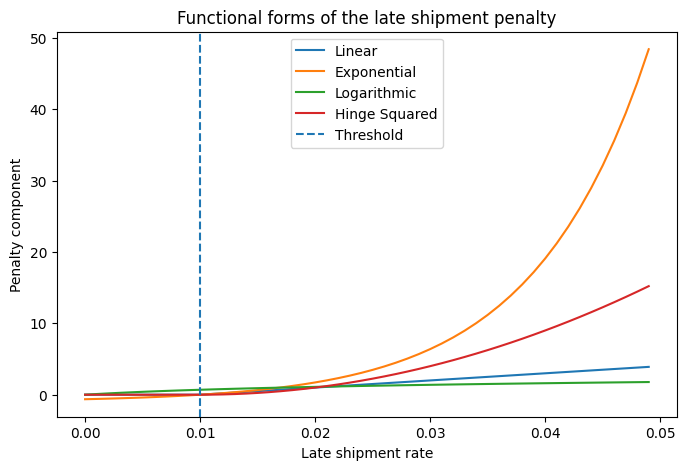

In [0]:
%python

pdf = df.toPandas()

plt.figure(figsize=(8,5))

plt.plot(pdf["pct_late_shipments"], pdf["linear"], label="Linear")
plt.plot(pdf["pct_late_shipments"], pdf["exponential"], label="Exponential")
plt.plot(pdf["pct_late_shipments"], pdf["logarithmic"], label="Logarithmic")
plt.plot(pdf["pct_late_shipments"], pdf["hinge_squared"], label="Hinge Squared")

plt.axvline(x=threshold, linestyle="--", label="Threshold")

plt.xlabel("Late shipment rate")
plt.ylabel("Penalty component")
plt.title("Functional forms of the late shipment penalty")

plt.legend()
plt.show()

## 3.5 - `fact_seller_index` – Final index construction
The final Seller Index is computed by aggregating the penalty components from each metric.

Operationally, late shipments are considered the most critical performance issue, as they directly affect delivery reliability and customer satisfaction. For this reason, the late shipment component receives double weight in the final penalty calculation. 

The total penalty is therefore calculated as:

$$ Total Penalty = 2 * late'component + cancel'component + claim'component
$$

The Seller Index is then constructed as a discrete score between 1 and 5:
$$
SellerIndex=max(1 , 5−|penalty|)
$$

This formulation ensures that each additional unit of penalty reduces the index by one level, while the minimum value is capped at 1.

The index calculation is performed three times, once for each functional form of the components (linear, quadratic, and square-root), allowing the impact of different penalty structures to be analyzed.

Finally, the Seller Index determines the percentage of shipping costs covered by Olist, according to the platform’s current operational policy: 

| Seller Index | Olist Shipping Coverage |
| ------------ | ----------------------- |
| 1–2          | 15%                     |
| 3            | 30%                     |
| 4–5          | 40%                     |

This mechanism directly links operational performance with financial incentives, encouraging sellers to maintain high service quality.

Both the seller_indexes and the shipping coverage are depicted in `fact_seller_index`.

# Graphical Analysis

### Time series - Avg. Seller Index

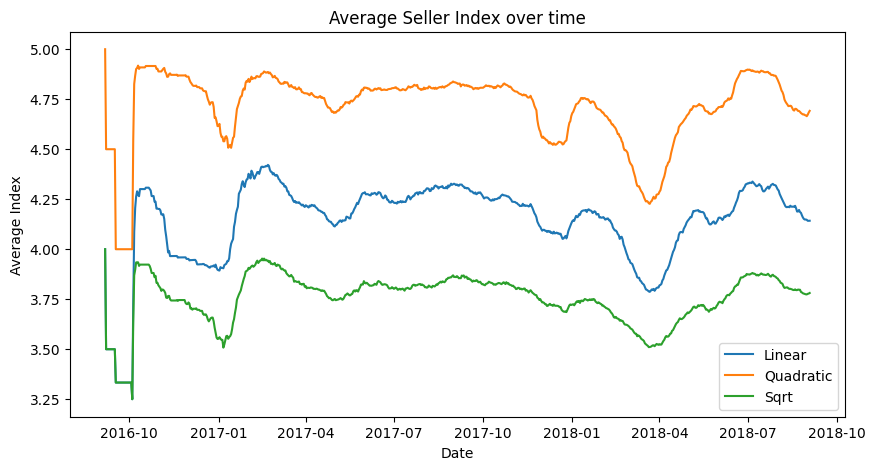

In [0]:
%python

df_time = (
    fact_seller_index
    .groupBy("reference_date")
    .agg(
        F.avg("seller_index_linear").alias("avg_index_linear"),
        F.avg("seller_index_quadratic").alias("avg_index_quadratic"),
        F.avg("seller_index_sqrt").alias("avg_index_sqrt"),
        F.countDistinct("seller_key").alias("active_sellers")
    )
    .orderBy("reference_date")
)

pdf = df_time.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(pdf["reference_date"], pdf["avg_index_linear"], label="Linear")
plt.plot(pdf["reference_date"], pdf["avg_index_quadratic"], label="Quadratic")
plt.plot(pdf["reference_date"], pdf["avg_index_sqrt"], label="Sqrt")

plt.title("Average Seller Index over time")
plt.xlabel("Date")
plt.ylabel("Average Index")
plt.legend()

plt.show()

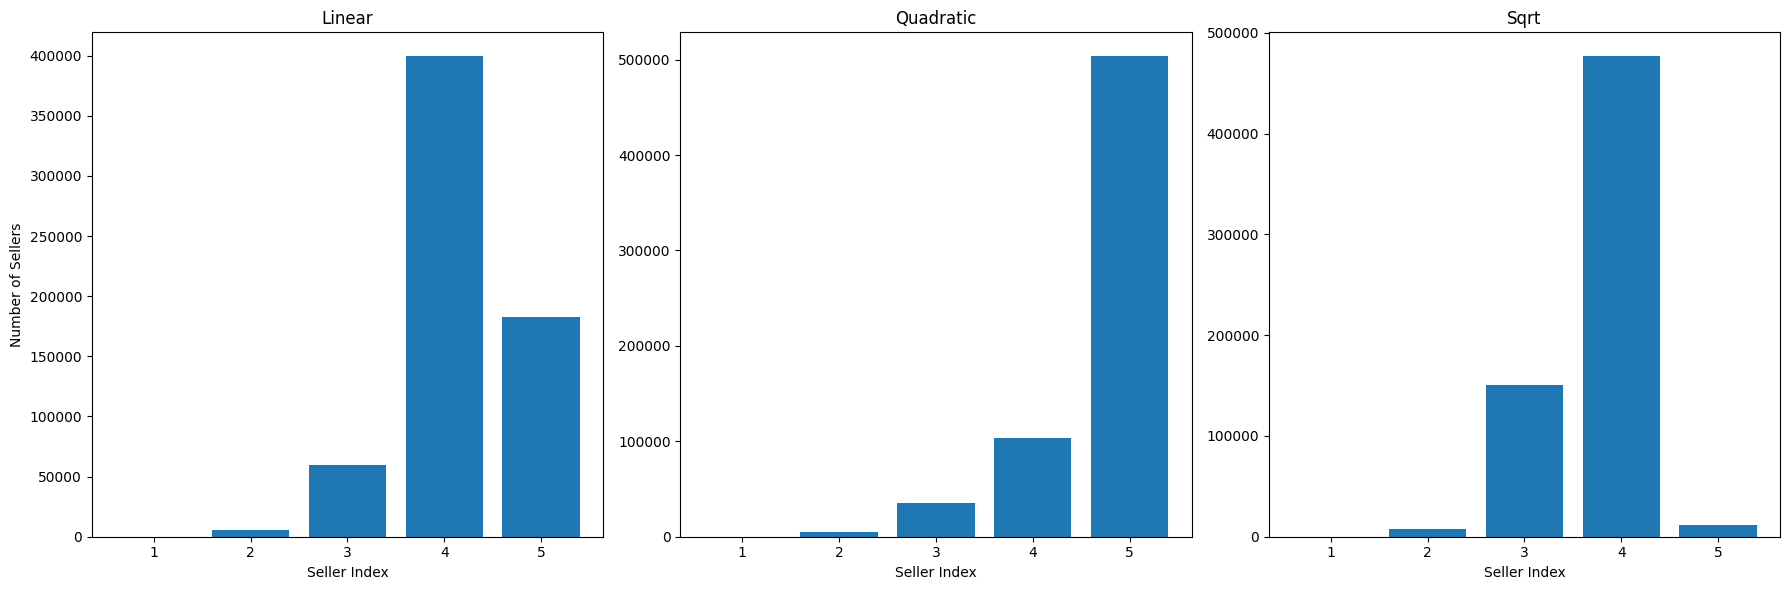

In [0]:
fig, axes = plt.subplots(1,3, figsize=(18,6))

# Linear
pdf = fact_seller_index.groupBy("seller_index_linear").count().toPandas()
axes[0].bar(pdf["seller_index_linear"], pdf["count"])
axes[0].set_title("Linear")
axes[0].set_xlabel("Seller Index")
axes[0].set_ylabel("Number of Sellers")

# Quadratic
pdf = fact_seller_index.groupBy("seller_index_quadratic").count().toPandas()
axes[1].bar(pdf["seller_index_quadratic"], pdf["count"])
axes[1].set_title("Quadratic")
axes[1].set_xlabel("Seller Index")

# Sqrt
pdf = fact_seller_index.groupBy("seller_index_sqrt").count().toPandas()
axes[2].bar(pdf["seller_index_sqrt"], pdf["count"])
axes[2].set_title("Sqrt")
axes[2].set_xlabel("Seller Index")

plt.tight_layout()
plt.show()

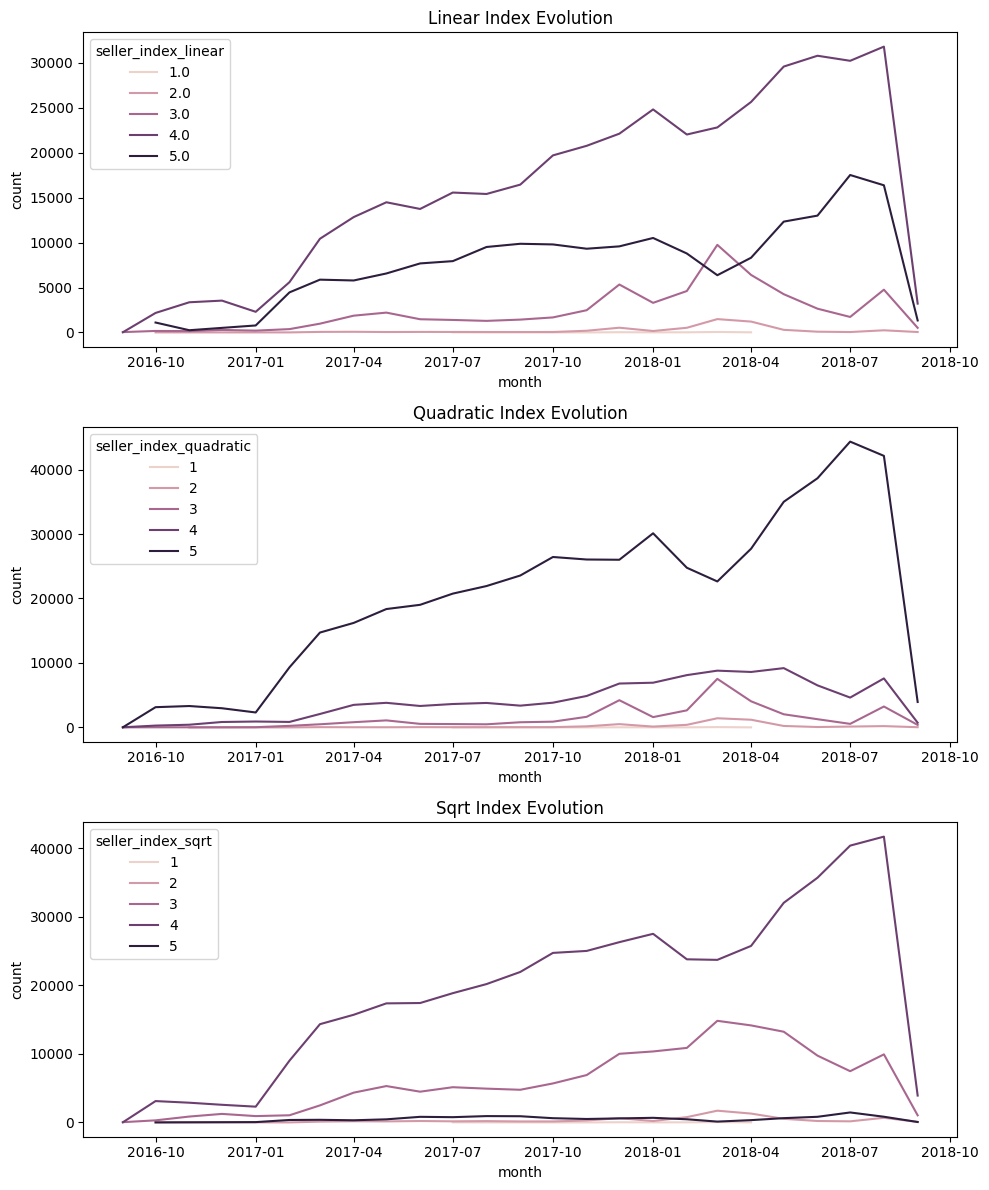

In [0]:

fig, axes = plt.subplots(3,1, figsize=(10,12))

# Linear
df_month = (
    fact_seller_index
    .withColumn("month", F.date_trunc("month","reference_date"))
    .groupBy("month","seller_index_linear")
    .count()
)
pdf = df_month.toPandas()

sns.lineplot(
    data=pdf,
    x="month",
    y="count",
    hue="seller_index_linear",
    ax=axes[0]
)
axes[0].set_title("Linear Index Evolution")

# Quadratic
df_month = (
    fact_seller_index
    .withColumn("month", F.date_trunc("month","reference_date"))
    .groupBy("month","seller_index_quadratic")
    .count()
)
pdf = df_month.toPandas()

sns.lineplot(
    data=pdf,
    x="month",
    y="count",
    hue="seller_index_quadratic",
    ax=axes[1]
)
axes[1].set_title("Quadratic Index Evolution")

# Sqrt
df_month = (
    fact_seller_index
    .withColumn("month", F.date_trunc("month","reference_date"))
    .groupBy("month","seller_index_sqrt")
    .count()
)
pdf = df_month.toPandas()

sns.lineplot(
    data=pdf,
    x="month",
    y="count",
    hue="seller_index_sqrt",
    ax=axes[2]
)
axes[2].set_title("Sqrt Index Evolution")

plt.tight_layout()
plt.show()

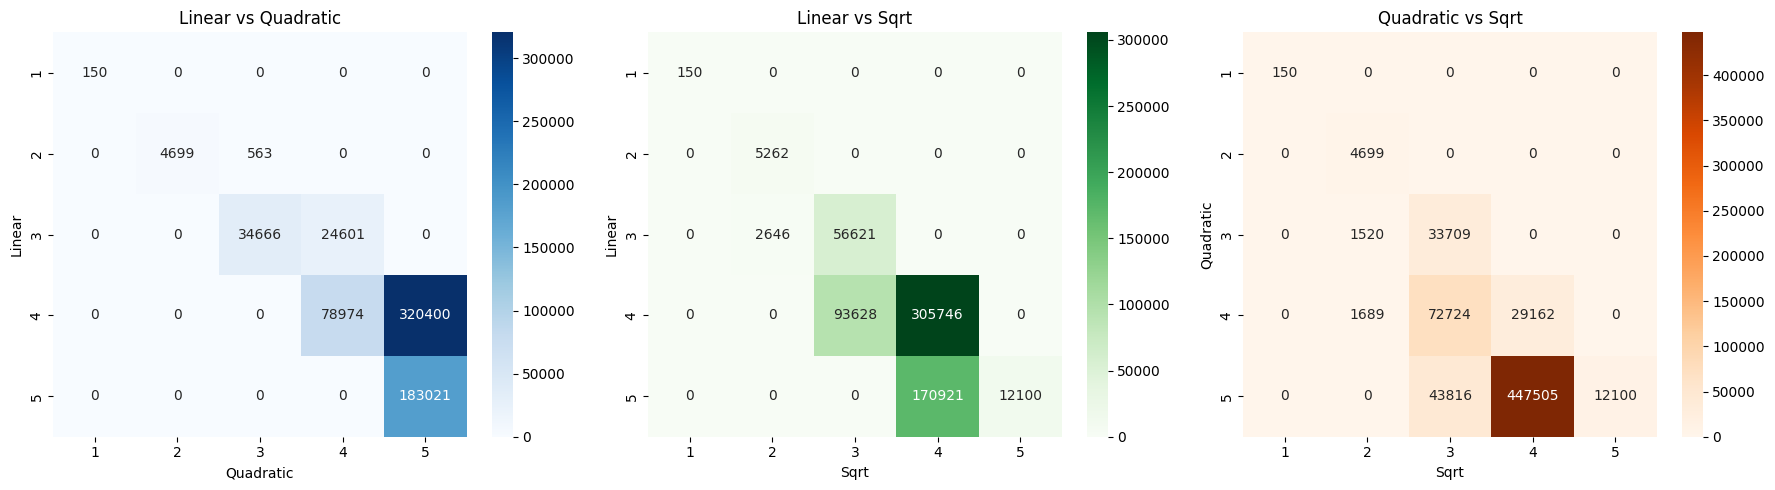

In [0]:

pdf = fact_seller_index.select(
    "seller_index_linear",
    "seller_index_quadratic",
    "seller_index_sqrt"
).toPandas()

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Linear vs Quadratic
sns.heatmap(
    pd.crosstab(
        pdf["seller_index_linear"],
        pdf["seller_index_quadratic"]
    ),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Linear vs Quadratic")
axes[0].set_xlabel("Quadratic")
axes[0].set_ylabel("Linear")


# Linear vs Sqrt
sns.heatmap(
    pd.crosstab(
        pdf["seller_index_linear"],
        pdf["seller_index_sqrt"]
    ),
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("Linear vs Sqrt")
axes[1].set_xlabel("Sqrt")
axes[1].set_ylabel("Linear")


# Quadratic vs Sqrt
sns.heatmap(
    pd.crosstab(
        pdf["seller_index_quadratic"],
        pdf["seller_index_sqrt"]
    ),
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[2]
)

axes[2].set_title("Quadratic vs Sqrt")
axes[2].set_xlabel("Sqrt")
axes[2].set_ylabel("Quadratic")

plt.tight_layout()
plt.show()